In [1]:
# ================================
# 1. Import Libraries
# ================================
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [3]:
# ================================
# 2. Load Dataset
# ================================
df = pd.read_csv("/content/Job_3_Resource_sentiment.csv")

print("First 5 rows:")
print(df.head())

print("\nColumns:", df.columns)

First 5 rows:
   2401  Borderlands  Positive  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

  im getting on borderlands and i will murder you all ,  
0  I am coming to the borders and I will kill you...     
1  im getting on borderlands and i will kill you ...     
2  im coming on borderlands and i will murder you...     
3  im getting on borderlands 2 and i will murder ...     
4  im getting into borderlands and i can murder y...     

Columns: Index(['2401', 'Borderlands', 'Positive',
       'im getting on borderlands and i will murder you all ,'],
      dtype='object')


In [4]:
# Assume column names (change if different)
text_column = df.columns[0]      # first column = text
label_column = df.columns[1]     # second column = sentiment

In [5]:
# ================================
# 3. Data Cleaning
# ================================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)        # remove urls
    text = re.sub(r'@\w+', '', text)           # remove mentions
    text = re.sub(r'[^a-zA-Z\s]', '', text)    # remove special chars
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [6]:
df[text_column] = df[text_column].apply(clean_text)

# Remove null values
df = df.dropna()

# ================================

In [7]:
# 4. Encode Labels
# ================================
label_encoder = LabelEncoder()
df[label_column] = label_encoder.fit_transform(df[label_column])

num_classes = len(label_encoder.classes_)
print("Classes:", label_encoder.classes_)

Classes: ['Amazon' 'ApexLegends' 'AssassinsCreed' 'Battlefield' 'Borderlands'
 'CS-GO' 'CallOfDuty' 'CallOfDutyBlackopsColdWar' 'Cyberpunk2077' 'Dota2'
 'FIFA' 'Facebook' 'Fortnite' 'Google' 'GrandTheftAuto(GTA)' 'Hearthstone'
 'HomeDepot' 'LeagueOfLegends' 'MaddenNFL' 'Microsoft' 'NBA2K' 'Nvidia'
 'Overwatch' 'PlayStation5(PS5)' 'PlayerUnknownsBattlegrounds(PUBG)'
 'RedDeadRedemption(RDR)' 'TomClancysGhostRecon' 'TomClancysRainbowSix'
 'Verizon' 'WorldOfCraft' 'Xbox(Xseries)' 'johnson&johnson']


In [8]:
# ================================
# 5. Train-Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    df[text_column],
    df[label_column],
    test_size=0.2,
    random_state=42,
    stratify=df[label_column]
)

In [9]:
# ================================
# 6. Tokenization & Padding
# ================================
vocab_size = 10000
max_length = 100

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post')

In [10]:
# ================================
# 7. Build LSTM Model
# ================================
model = Sequential()

model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_length))
model.add(LSTM(128, return_sequences=False))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))

if num_classes == 2:
    model.add(Dense(1, activation='sigmoid'))
    loss_function = 'binary_crossentropy'
else:
    model.add(Dense(num_classes, activation='softmax'))
    loss_function = 'sparse_categorical_crossentropy'

model.compile(
    optimizer='adam',
    loss=loss_function,
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
# ================================
# 8. Train Model
# ================================
history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/10
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 29s 12ms/step - accuracy: 0.0302 - loss: 3.4673 - val_accuracy: 0.0321 - val_loss: 3.4658
Epoch 2/10
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - accuracy: 0.0307 - loss: 3.4663 - val_accuracy: 0.0319 - val_loss: 3.4656
Epoch 3/10
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 43s 16ms/step - accuracy: 0.0337 - loss: 3.4659 - val_accuracy: 0.0321 - val_loss: 3.4658
Epoch 4/10
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.0305 - loss: 3.4659 - val_accuracy: 0.0319 - val_loss: 3.4656
Epoch 5/10
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.0322 - loss: 3.4656 - val_accuracy: 0.0320 - val_loss: 3.4656
Epoch 6/10
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.0321 - loss: 3.4661 - val_accuracy: 0.0321 - val_loss: 3.4656
Epoch 7/10
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.0321 - loss: 3.4659 - val_accuracy: 0.0321 - val_loss: 3.4656
Epoch 8/10
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.0332 -

In [13]:
# ================================
# 9. Evaluation
# ================================
loss, accuracy = model.evaluate(X_test_pad, y_test)
print("\nTest Accuracy:", accuracy)

463/463 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0315 - loss: 3.4655

Test Accuracy: 0.03209676221013069


In [14]:
# Predictions
y_pred = model.predict(X_test_pad)

if num_classes == 2:
    y_pred_classes = (y_pred > 0.5).astype("int32")
else:
    y_pred_classes = np.argmax(y_pred, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_classes))

463/463 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       455
           1       0.00      0.00      0.00       471
           2       0.00      0.00      0.00       447
           3       0.00      0.00      0.00       463
           4       0.00      0.00      0.00       456
           5       0.00      0.00      0.00       457
           6       0.00      0.00      0.00       475
           7       0.00      0.00      0.00       469
           8       0.00      0.00      0.00       452
           9       0.00      0.00      0.00       472
          10       0.00      0.00      0.00       465
          11       0.00      0.00      0.00       472
          12       0.00      0.00      0.00       450
          13       0.00      0.00      0.00       455
          14       0.00      0.00      0.00       459
          15       0.00      0.00      0.00       457
          16    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


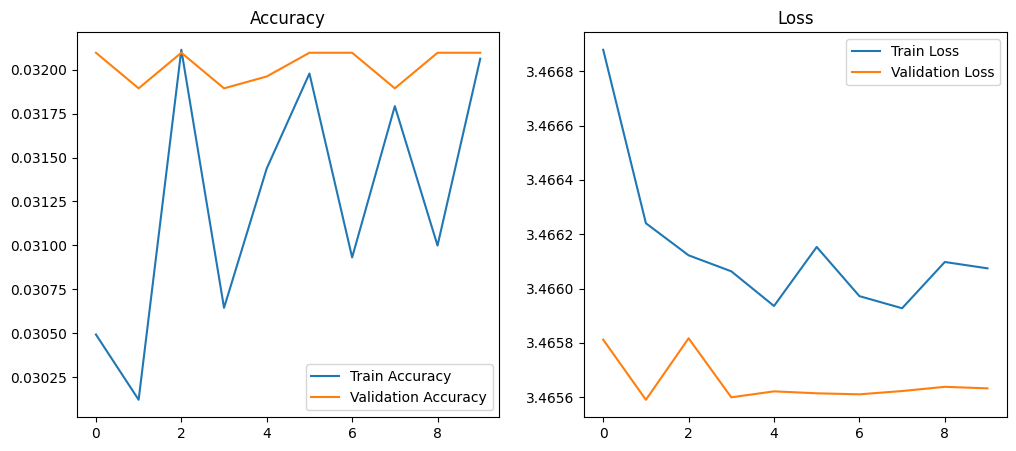

In [15]:
# ================================
# 10. Plot Accuracy & Loss
# ================================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")

plt.show()

In [16]:
# ================================
# 11. Prediction Function
# ================================
def predict_sentiment(text):
    text = clean_text(text)
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=max_length, padding='post')
    prediction = model.predict(pad)

    if num_classes == 2:
        class_index = int(prediction[0] > 0.5)
    else:
        class_index = np.argmax(prediction)

    sentiment = label_encoder.inverse_transform([class_index])[0]
    return sentiment

In [17]:
# ================================
# 12. Test Custom Sentence
# ================================
sample_text = "This resource is very helpful and amazing!"
print("Prediction:", predict_sentiment(sample_text))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Prediction: LeagueOfLegends


In [18]:
# ================================
# 13. Save Model
# ================================
model.save("sentiment_lstm_model.h5")
print("Model saved as sentiment_lstm_model.h5")

Model saved as sentiment_lstm_model.h5


In [19]:
# ================================
# 13. Save Model
# ================================
model.save("sentiment_lstm_model.keras")
print("Model saved as sentiment_lstm_model.keras")

Model saved as sentiment_lstm_model.keras
